## Simulation experiment 1
2026-05-03

Motivation: 
The HK416 A5 (10.4" barrel) offers the best recoil-to-weight ratio of any rifle in the catalog (~57% vs M249's ~49%), while being much lighter (3.0 kg vs 7.5 kg body). Its 5.56x45 NATO round produces ~5.5 N·s impulse at 850 RPM → ~79 N average recoil thrust. The lighter total drone mass (~5.9 kg) gives more headroom for agile evasion maneuvers.

Objective: 
Train an RL agent to aim and fire the HK416 at a single stationary target using PPO fine-tuned from a BC hover policy.

Stats: 
HK416 A5 (5.56x45 NATO, 10.4" barrel, 850 RPM, 30-round STANAG mag)
No wind

Notes:
- BC pretrained on ZeroTargetEnv with hk416 gun mass
- Fire cold-start fix applied (weight row zeroed, bias=+1, log_std=0)
- Curriculum: 5 m → 20 m → 50 m → 100 m+ once hitting consistently

In [2]:
import torch
import matplotlib.pyplot as plt

from drone_sim.control.controller import quat_to_euler, wrap_pi
from drone_sim.rl.custom_envs import SingleTargetEnv
from drone_sim.rl.callbacks import ShotStatsCallback
from drone_sim.sim import quat_to_rot

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [3]:
# Curriculum: start with a close target so target_rel_norm ~ [1,0,0] at spawn
# and the cosine aiming reward provides an immediate gradient. Scale up once
# the policy reliably shoots (ep_len stable at 400+, hits > 0 per episode).
TARGET_RADIUS = 5.0   # start at 5 m; increase to 20m, increase to 50, then 100, then 200 (because the distance is capped to 100, so see if the agent can come closer) once hitting consistently

vec_env = make_vec_env(
    lambda: SingleTargetEnv(
        control_level='thrust',
        target_radius=TARGET_RADIUS,
        action_pos_range_m=TARGET_RADIUS + 10.0,
        reward_cfg={
            "hit": 75.0,
            "aim": 0.03, # 0.03
            "miss_dist": 0.05, #0.05
            "ammo": 0.005,
            "stability": 0.01,
            "crash": 100.0,
        }
    ),
    n_envs=4,
)

In [3]:
# SplitExtractor must be imported (done above) so SB3 can reconstruct the policy.
# If loading a model saved before the SplitExtractor architecture was introduced,
# omit the custom_objects kwarg — SB3 will use the flat MLP stored in the zip.
model = PPO.load(
    "../experiment-1/ppo_e-1_bc",
    env=vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
)

In [4]:
# --- Fire action cold-start fix ---
#
# Two things drive fire → never after training on ZeroTargetEnv:
#   1. action_net.bias[4]   ≈ -1.0  (constant offset)
#   2. action_net.weight[4, :]  negative weights  (state pushes it further down)
# Resetting the bias alone shifts the mean by +2, but the weight row can still
# dominate (e.g. weight contribution = -3 → net mean = -2, P(fire>0) ≈ 2%).
#
# Fix: zero the weight row so fire_mean = bias only (state-independent),
# then bias = +1.0 → P(fire > 0) = Φ(1/1.0) ≈ 84%.  Hover weights untouched.
with torch.no_grad():
    model.policy.action_net.weight.data[4, :] = 0.0   # remove state→fire coupling
    model.policy.action_net.bias.data[4]      = 1.0   # fire mean = +1
    model.policy.log_std.data[4]              = 0.0   # fire std = e^0 = 1.0

print(f"Fire weight norm (should be 0): {model.policy.action_net.weight.data[4].norm().item():.4f}")
print(f"Fire mean (bias):  {model.policy.action_net.bias.data[4].item():.2f}")
print(f"Fire log_std:      {model.policy.log_std.data[4].item():.2f}  →  std = {model.policy.log_std.data[4].exp().item():.2f}")
print(f"Thrust log_std:    {model.policy.log_std.data[0].item():.2f}  →  std = {model.policy.log_std.data[0].exp().item():.3f}")
print(f"P(fire > 0) ≈ 84.1%  (Φ(1) with mean=1, std=1)")

Fire weight norm (should be 0): 0.0000
Fire mean (bias):  1.00
Fire log_std:      0.00  →  std = 1.00
Thrust log_std:    -2.56  →  std = 0.077
P(fire > 0) ≈ 84.1%  (Φ(1) with mean=1, std=1)


In [5]:
model.learn(
    total_timesteps=1000000,
    reset_num_timesteps=False,
    callback=ShotStatsCallback(print_freq=10),
)
model.save("ppo_e1_5m_hk416")

[ep    10]  shots/ep=  17.0  hits/ep=0.00
[ep    20]  shots/ep=  18.2  hits/ep=0.00
[ep    30]  shots/ep=  17.9  hits/ep=0.00
[ep    40]  shots/ep=  17.9  hits/ep=0.00
[ep    50]  shots/ep=  19.5  hits/ep=0.00
[ep    60]  shots/ep=  19.2  hits/ep=0.00
[ep    70]  shots/ep=  18.5  hits/ep=0.00
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 184      |
|    ep_rew_mean      | 102      |
| shots/              |          |
|    mean_hits_per_ep | 0        |
|    mean_per_ep      | 18.5     |
| time/               |          |
|    fps              | 1230     |
|    iterations       | 1        |
|    time_elapsed     | 6        |
|    total_timesteps  | 16384    |
----------------------------------
[ep    80]  shots/ep=  18.1  hits/ep=0.00
[ep    90]  shots/ep=  18.2  hits/ep=0.00
[ep   100]  shots/ep=  16.7  hits/ep=0.00
[ep   110]  shots/ep=  18.1  hits/ep=0.00
[ep   120]  shots/ep=  17.8  hits/ep=0.00
[ep   130]  shots/ep=  16.6  hits/ep=0.00

In [ ]:
# SplitExtractor must be imported (done above) so SB3 can reconstruct the policy.
# If loading a model saved before the SplitExtractor architecture was introduced,
# omit the custom_objects kwarg — SB3 will use the flat MLP stored in the zip.
model = PPO.load(
    "../experiment1/ppo_e1_5m_hk416",
    env=vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
)

[ep    10]  shots/ep=  26.4  hits/ep=0.90
[ep    20]  shots/ep=  25.2  hits/ep=2.30
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 361      |
|    ep_rew_mean      | 211      |
| shots/              |          |
|    mean_hits_per_ep | 2.3      |
|    mean_per_ep      | 25.2     |
| time/               |          |
|    fps              | 2091     |
|    iterations       | 1        |
|    time_elapsed     | 3        |
|    total_timesteps  | 1024000  |
----------------------------------


KeyboardInterrupt: 

In [ ]:
model.learn(
    total_timesteps=1000000,
    reset_num_timesteps=False,
    callback=ShotStatsCallback(print_freq=10),
)
model.save("ppo_e1_5m_hk416")

In [8]:
TARGET_RADIUS = 20.0   # start at 5 m; increase to 20m, increase to 50, then 100, then 200 (because the distance is capped to 100, so see if the agent can come closer) once hitting consistently

vec_env = make_vec_env(
    lambda: SingleTargetEnv(
        control_level='thrust',
        target_radius=TARGET_RADIUS,
        action_pos_range_m=TARGET_RADIUS + 10.0,
        reward_cfg={
            "hit": 75.0,
            "aim": 0.03, # 0.03
            "miss_dist": 0.05, #0.05
            "ammo": 0.005,
            "stability": 0.01,
            "crash": 100.0,
            "min_dist_m": 5.0,
            "min_dist_pen": 2.0,
        }
    ),
    n_envs=4,
)

In [ ]:
model = PPO.load(
    "../experiment1/ppo_e1_5m_hk416",
    env=vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
)

In [11]:
model.learn(
    total_timesteps=1000000,
    reset_num_timesteps=False,
    callback=ShotStatsCallback(print_freq=10),
)
model.save("ppo_e1_20m_hk416")

[ep    10]  shots/ep=  24.9  hits/ep=0.00
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 394      |
|    ep_rew_mean      | 178      |
| shots/              |          |
|    mean_hits_per_ep | 0        |
|    mean_per_ep      | 24.9     |
| time/               |          |
|    fps              | 2087     |
|    iterations       | 1        |
|    time_elapsed     | 3        |
|    total_timesteps  | 1028932  |
----------------------------------
[ep    20]  shots/ep=  29.4  hits/ep=0.00
[ep    30]  shots/ep=  27.2  hits/ep=0.10
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 407        |
|    ep_rew_mean          | 140        |
| shots/                  |            |
|    mean_hits_per_ep     | 0.1        |
|    mean_per_ep          | 27.2       |
| time/                   |            |
|    fps                  | 1293       |
|    iterations           | 2          |
|    time

In [ ]:
TARGET_RADIUS = 30.0   # start at 5 m; increase to 20m, increase to 50, then 100, then 200 (because the distance is capped to 100, so see if the agent can come closer) once hitting consistently

vec_env = make_vec_env(
    lambda: SingleTargetEnv(
        control_level='thrust',
        target_radius=TARGET_RADIUS,
        action_pos_range_m=TARGET_RADIUS + 10.0,
        reward_cfg={
            "hit": 100.0,
            "aim": 0, # 0.03
            "miss_dist": 0, #0.05
            "ammo": 0,
            "stability": 0,
            "crash": 100.0,
            "min_dist_m": 5.0,
            "min_dist_pen": 2.0,
        },
        # spawn_heading="random"
    ),
    n_envs=4,
)

model = PPO.load(
    "../experiment1/ppo_e1_30m_hk416",
    env=vec_env,
    learning_rate=1e-4,
    ent_coef=0.01,
)

In [ ]:
model.learn(
    total_timesteps=500000,
    reset_num_timesteps=False,
    callback=ShotStatsCallback(print_freq=10),
)
model.save("ppo_e1_30m_hk416_b")

Episode ended at step 500  (truncated)
Video saved → e1_HK416_10m.mp4
Steps: 500 / 500  |  Total reward: 853.2  |  Hits: 23


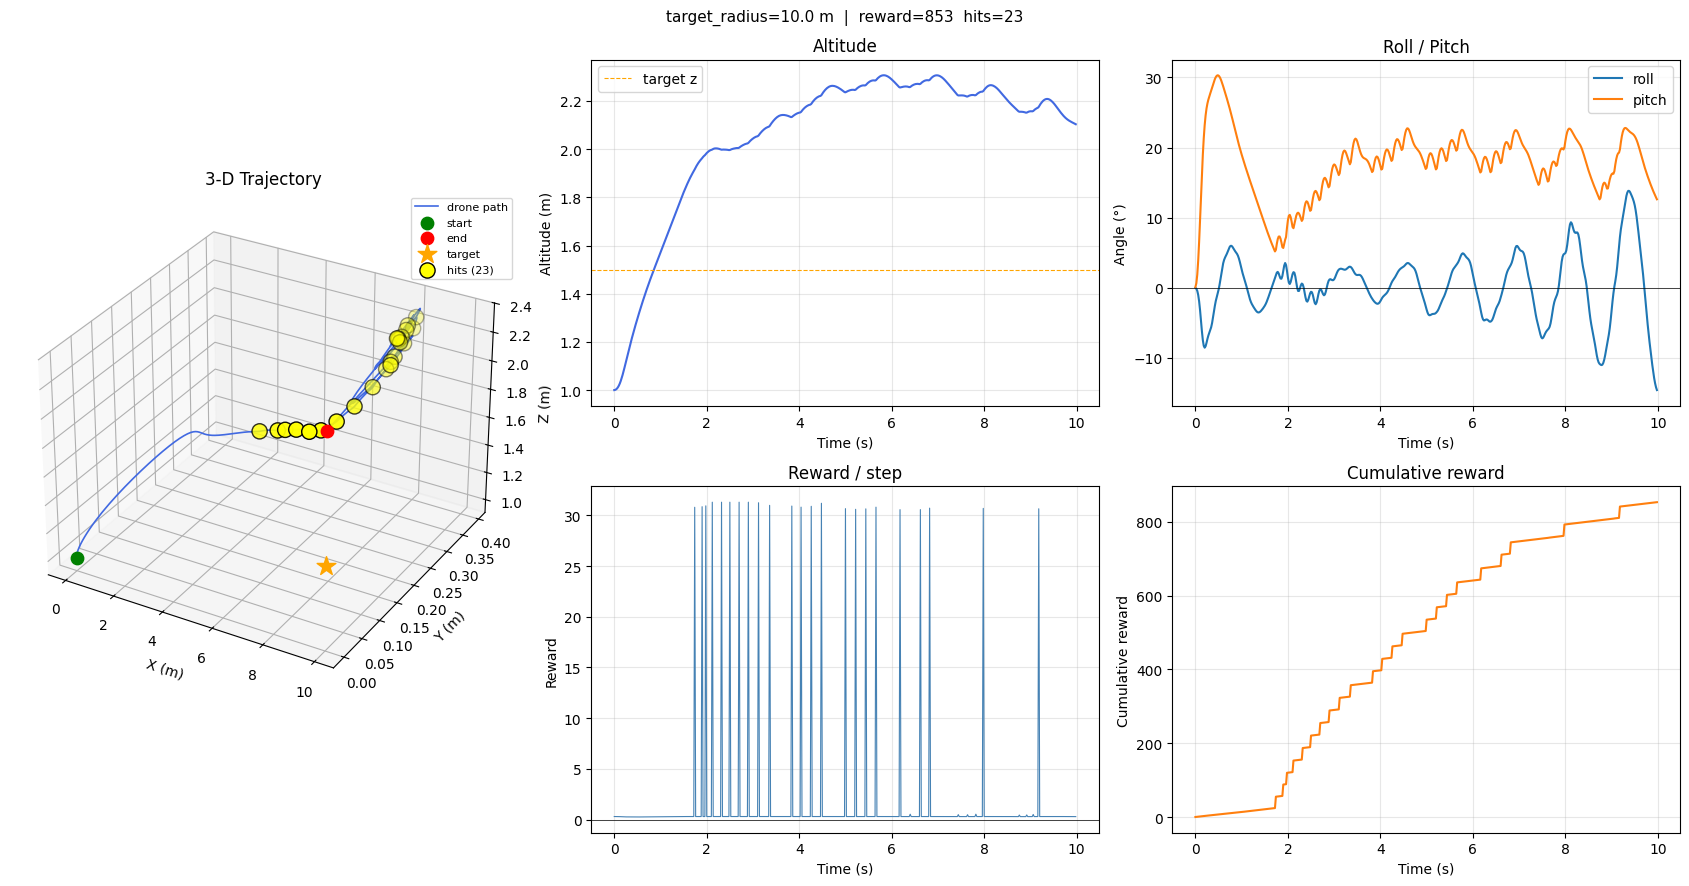

In [ ]:
from drone_sim.rl.viz import visualize_episode

positions, rewards = visualize_episode(model, save_video="e1_HK416_30m.mp4", target_radius=TARGET_RADIUS, speed=1.0)
#positions, rewards = visualize_episode(model, target_radius=TARGET_RADIUS, speed=1.0)

 step    reward         cum   hits  ammo
--------------------------------------------
   20     +0.21       +5.68      0    26
   24     +0.10       +6.26      0    25
--------------------------------------------
end: terminated=True truncated=False final cumulative reward = +6.26
plot saved to pid_agent_reward.png


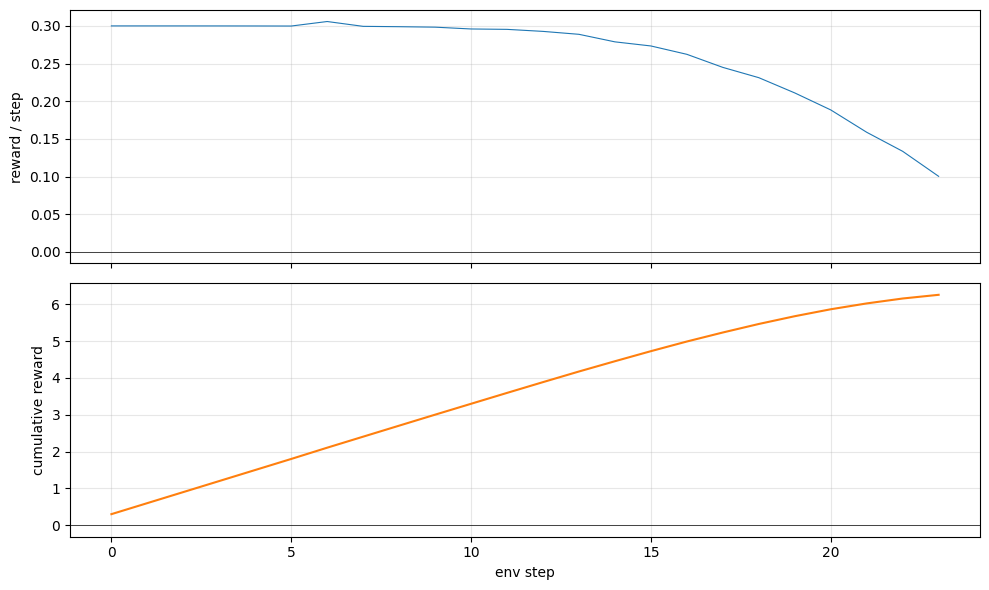

In [ ]:
env = SingleTargetEnv(
    target_height=1.5,
    seed=42,
    max_episode_steps=1000,
    render_mode="human",
)

rewards = run_episode(env, model, render=True)
env.close()

plot_rewards(rewards)